First:
- go to the terminal
- go to the `4_tuning_networks` folder, use `cd` to get there, or `z` to get there faster.
- if you are planning on closing the laptop to let this run by itself, start a tmux session by giving the command `tmux`. You can name the session with `ctrl+b $`, leave the tmux with `ctrl+b` d, access it again with `tmux a -t 0` or replace the 0 with the name you gave it. See [tmux](https://github.com/tmux/tmux/wiki/Getting-Started) for more info.
- Activate the `.venv`, and run `python hypertune.py`
- In the hypertune.py file, a tune_dir is specified: `models/ray`. We will check the contents of that folder after the hypertune finished. You can also use tensorboard to check the results. 
- this will take some time. I clocked 1901 seconds (30 minutes) on the VM

 0.0992908 |           119 |            3 |     26 |         576.744  |    0 |   0.942187

In [3]:
from pathlib import Path
tune_dir = Path("logs/ray").resolve()
tune_dir.exists()

True

In [4]:
tunelogs = [d for d in tune_dir.iterdir()]
tunelogs.sort()
latest = tunelogs[-1]
latest

PosixPath('/Users/nickreinders/Documents/Master_Applied_Data_Science_deeltijd_HAN/Deployment/Raoul_repo/MADS-MachineLearning-course/notebooks/4_tuning_networks/logs/ray/train_2025-10-04_08-55-56')

In [5]:
from ray.tune import ExperimentAnalysis
import ray
ray.init(ignore_reinit_error=True)


analysis = ExperimentAnalysis(latest)


2025-10-04 16:39:59,692	INFO worker.py:1888 -- Started a local Ray instance.


So, we find some info:

In [6]:
analysis.results_df.columns


Index(['iterations', 'train_loss', 'test_loss', 'Accuracy', 'timestamp',
       'checkpoint_dir_name', 'done', 'training_iteration', 'date',
       'time_this_iter_s', 'time_total_s', 'pid', 'hostname', 'node_ip',
       'time_since_restore', 'iterations_since_restore', 'experiment_tag',
       'config/input_size', 'config/output_size', 'config/hidden_size',
       'config/dropout', 'config/num_layers'],
      dtype='object')

Let's focus on the parameters we wanted to tune.

In [7]:
import plotly.express as px

plot = analysis.results_df
select = ["Accuracy", "config/hidden_size", "config/dropout", "config/num_layers"]
p = plot[select].reset_index().dropna()


Let's sort by accuracy

In [8]:
p.sort_values("Accuracy", inplace=True)

Make a parallel plot

In [9]:
px.parallel_coordinates(p, color="Accuracy")


<Axes: xlabel='config/hidden_size', ylabel='config/num_layers'>

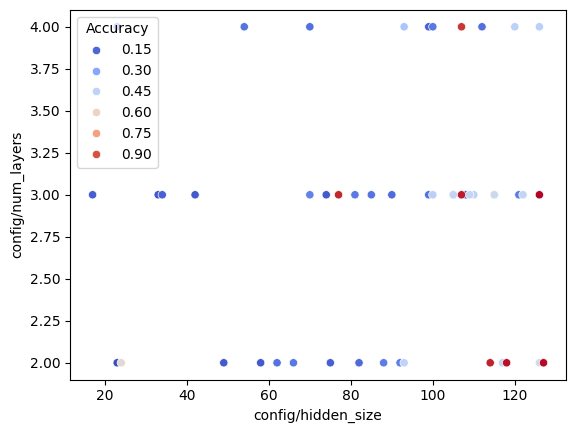

In [10]:
import seaborn as sns

sns.scatterplot(data=p, x="config/hidden_size", y="config/num_layers", hue="Accuracy", palette="coolwarm")

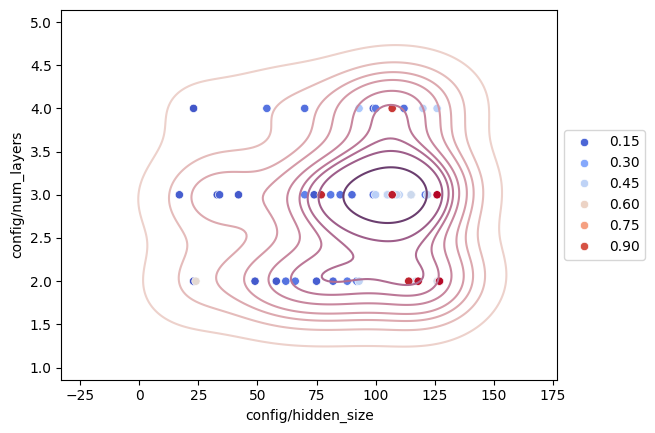

In [11]:
import matplotlib.pyplot as plt
cmap = sns.cubehelix_palette(as_cmap=True)
sns.scatterplot(data=p, x="config/hidden_size", y="config/num_layers", hue="Accuracy", palette="coolwarm")
sns.kdeplot(data=p, x="config/hidden_size", y="config/num_layers", cmap=cmap)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

Get the best trial

In [12]:
analysis.get_best_trial(metric="test_loss", mode="min")


train_cd3e9fd2

The top ten

In [13]:
p[-10:]


,trial_id,Accuracy,config/hidden_size,config/dropout,config/num_layers
47,3121ca43,0.509375,126,0.090741,2
0,d54e7203,0.568750,24,0.097402,2
7,328e888e,0.937500,107,0.086803,4
5,4860f627,0.959375,77,0.026937,3
49,edf84a8e,0.964063,114,0.097899,2
1,3c8140af,0.970313,107,0.231316,3
48,9b93a537,0.978125,127,0.114222,2
8,690f8fe1,0.978125,118,0.158315,2
27,b776dd7d,0.982812,127,0.104135,2
31,cd3e9fd2,0.989062,126,0.293361,3


Or the best config

In [14]:
analysis.get_best_config(metric="Accuracy", mode="max")


{'input_size': 3,
 'output_size': 20,
 'data_dir': PosixPath('/Users/nickreinders/Documents/Master_Applied_Data_Science_deeltijd_HAN/Deployment/Raoul_repo/MADS-MachineLearning-course/notebooks/4_tuning_networks/data/raw/gestures/gestures-dataset'),
 'hidden_size': 126,
 'dropout': 0.29336123692218813,
 'num_layers': 3}